## Train Bayesian Neural Network Parameterisation

In this notebook we train a Bayesian neural network (BNN) parameterisation that again learns a mapping from the resolved variables $X$ to the subgrid-scale forcing $U$, but now with uncertainty estimates.

Compared with the deterministic NN in Notebook 2, the BNN places a distribution over network weights and uses variational inference (VI) to approximate the posterior. This gives us epistemic uncertainty, due to lack of knowledge in the parameters. We are also using a BNN that predicts not just a single output, but a mean and a variance, capturing the aleatoric uncertainty, the inherent variability in the training data.

This allows us to develop stochastic parameterisations that sample epistemic uncertainty, aleatoric uncertainty, or both, which we can use online in the L96 model to evaluate how these sources of uncertainty propagate across weather and climate timescales.

This notebook focuses on training the BNN. We follow a similar structure to the notebook that trains our deterministic NN, but replace the loss with the evidence lower bound (ELBO) optimised via stochastic variational inference using Pyro (see the paper and Supplementary Material for more details).

In [13]:
import os
import numpy as np
import matplotlib.pyplot as plt
from collections import OrderedDict

import torch
from torch.utils.data import TensorDataset, DataLoader

import pyro
import pyro.distributions as dist
from pyro.infer.autoguide import AutoMultivariateNormal
from pyro.infer import SVI, Trace_ELBO, Predictive
from pyro.optim import Adam as PyroAdam

from ml_models.BayesianModels import BayesianNN_Heteroscedastic
from plotting_scripts.plot_data_histogram import plot_hist

In [14]:
# Random seed
seed = 123
np.random.seed(seed)
torch.manual_seed(seed)

# Define dimensions of system (fixed)
K = 8   
J = 32  

# Define the parameters
h = 1
F = 20
c = 10
b = 10

# Define time-stepping
dt = 0.001        # Two layer (high-res) run at dt
dt_f = 0.005      # One layer (coarse-res) run at dt_f


In [15]:
# Data path should already exist as we have already run the notebook to generate training data
# Here we reuse the same training data (X, U) as in the deterministic NN notebook.
data_path = "./outputs/"
X = np.load(os.path.join(data_path, "X_train_dtf.npy"))
U = np.load(os.path.join(data_path, "U_train_dtf.npy"))
print(f"Data loaded from {data_path}")
print("X shape:", X.shape, "U shape:", U.shape)

# Optional: subsample in time to reduce temporal correlation between samples
subsample = 100  # adjust if you want more / fewer samples - we reduce samples to speed up inference
X = X[::subsample]
U = U[::subsample]
print("After subsampling:", X.shape, U.shape)

Data loaded from ./outputs/
X shape: (19999, 8) U shape: (19999, 8)
After subsampling: (200, 8) (200, 8)


### Training configuration and data preparation

### Data processing: Training, validation, and test split

Here we choose how much data to use for training, validation, and testing, and set our hyperparameters:

- `N_TRAIN`: number of samples used to fit the BNN
- `N_VAL`: number of samples held out as a validation set to monitor during training.
- `N_TEST`: number of samples held out at the end of the dataset for final testing.
- `BATCH_SIZE`: number of each minibatch (for the ELBO estimates).
- `NUM_EPOCHS`: number of optimisation iterations for the stochastic VI.
- `LR`: learning rate for the optimiser


We then reshape the `X` and `U` arrays into 1D feature/target tensors compatible with our BNN.

In [16]:
N_TRAIN = 100
N_VAL = 100
BATCH_SIZE = 128
NUM_EPOCHS = 20000
LR = 3e-4

N = X.shape[0]
print(f"Total size of data: {N} x {K} = {N*K}")

features = np.ravel(X[:N_TRAIN])   
targets = np.ravel(U[:N_TRAIN])   

features_val = np.ravel(X[N_TRAIN:N_TRAIN + N_VAL])   
targets_val = np.ravel(U[N_TRAIN:N_TRAIN + N_VAL])    

print(f"Training: {features.shape}, {targets.shape}, \n\
Validation: {features_val.shape}, {targets_val.shape}")


Total size of data: 200 x 8 = 1600
Training: (800,), (800,), 
Validation: (800,), (800,)


In [17]:

X_torch = torch.tensor(features, dtype=torch.float32).reshape((-1, 1))
Y_torch = torch.tensor(targets, dtype=torch.float32).reshape((-1, 1))

X_val = torch.tensor(features_val, dtype=torch.float32).reshape((-1, 1))
Y_val = torch.tensor(targets_val, dtype=torch.float32).reshape((-1, 1))

dataset = TensorDataset(X_torch, Y_torch)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

dataset_val = TensorDataset(X_val, Y_val)
dataloader_val = DataLoader(dataset_val, batch_size=N_VAL, shuffle=True)


## Define BNN model and variational guide


In [18]:
# One-dimensional input and output, with two hidden layers [16, 16]
model = BayesianNN_Heteroscedastic(1, 1, [16, 16])
# Choose variational distribution - we use a multivariate normal
guide = AutoMultivariateNormal(model)

print(model)
print(guide)

BayesianNN_Heteroscedastic(
  (layers): PyroModuleList(
    (0): PyroLinear(in_features=1, out_features=16, bias=True)
    (1): PyroLinear(in_features=16, out_features=16, bias=True)
    (2): PyroLinear(in_features=16, out_features=2, bias=True)
  )
  (activation_function): ReLU()
)
AutoMultivariateNormal()


In [19]:
# Set up SVI (stochastic variational inference)
pyro.clear_param_store()

optimizer = PyroAdam({"lr":LR})
elbo = Trace_ELBO()
svi = SVI(model, guide, optimizer, loss=elbo)

losses = []
val_losses = []
min_loss = float("inf")


In [20]:

for iteration in range(NUM_EPOCHS):
    epoch_loss = 0.0
    for X_batch, Y_batch in dataloader:
        loss = svi.step(X_batch, Y_batch)
        epoch_loss += loss / X_batch.shape[0]
    
    #epoch_loss /= len(dataloader)
    losses.append(epoch_loss)

    with torch.no_grad(): 
        val_losses.append(Trace_ELBO().loss(model, guide, X_val, Y_val))
   
    # Save best checkpoint so far
    if val_losses[-1] < min_loss:
        checkpoint = {
            "iteration": iteration,
            "train_loss": losses,
            "val_loss":val_losses,
            "model": model,
            "guide": guide,
        }
        torch.save(checkpoint, f"{data_path}/model_best.pt")
        pyro.get_param_store().save(f"{data_path}/pyro_best_params.pt")
        min_loss = val_losses[-1]

    if iteration % 1000 == 0:
        print(f"[iteration {iteration:05d}] ELBO loss: {epoch_loss:.3f}, \
        val loss:{val_losses[-1]}")

print("Done training")


[iteration 00000] ELBO loss: 578750.048,         val loss:216458.27975463867
[iteration 01000] ELBO loss: 289.416,         val loss:4666.278350830078
[iteration 02000] ELBO loss: 85.235,         val loss:3643.0099487304688
[iteration 03000] ELBO loss: 78.044,         val loss:3575.6791381835938
[iteration 04000] ELBO loss: 68.738,         val loss:4727.2406005859375
[iteration 05000] ELBO loss: 69.163,         val loss:3415.878143310547
[iteration 06000] ELBO loss: 58.343,         val loss:2446.5322265625
[iteration 07000] ELBO loss: 55.375,         val loss:2961.62158203125
[iteration 08000] ELBO loss: 45.931,         val loss:2732.3858032226562
[iteration 09000] ELBO loss: 36.990,         val loss:2075.74365234375
[iteration 10000] ELBO loss: 30.069,         val loss:2141.3695373535156
[iteration 11000] ELBO loss: 27.713,         val loss:1980.9737548828125
[iteration 12000] ELBO loss: 26.201,         val loss:2000.3901977539062
[iteration 13000] ELBO loss: 26.310,         val loss:1

Text(0, 0.5, 'ELBO loss')

<Figure size 640x480 with 0 Axes>

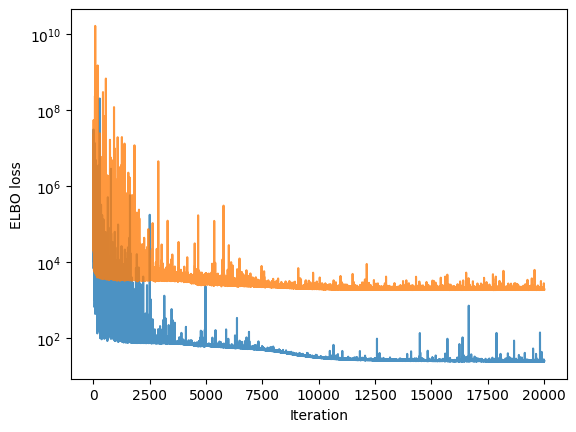

In [21]:
# Plot and save training loss
plt.clf()
fig, ax = plt.subplots(1, 1)
ax.semilogy(losses, label="Training",alpha=0.8)
ax.semilogy(val_losses, label="Validation",alpha=0.8)

ax.set_xlabel("Iteration")
ax.set_ylabel("ELBO loss")


## Plot

In [22]:
Xmin, Xmax, Ymin, Ymax = -9, 16, -22, 22


In [23]:
# Plot inputs and outputs and the estimated uncertainties
# Generate posterior samples for deterministic prediction (mean/median)
num_samples = 1000
sample_dicts = [guide() for _ in range(num_samples)]  # list of OrderedDicts

# Stack each parameter: shape becomes (num_samples, *param_shape)
posterior_samples = OrderedDict( (k, torch.stack([sd[k] for sd in sample_dicts], dim=0))
    for k in sample_dicts[0].keys()
)
# Prepare predictive
num_samples = 1000
predictive = Predictive(model, guide=guide, num_samples=num_samples,
                    return_sites=("obs", "_RETURN"))
X_domain = torch.linspace(Xmin, Xmax, 80).unsqueeze(-1)
# Predictive 
samples = predictive(X_domain)


/var/folders/3q/gycsc7sn55z3nwf583zm7k9c0000gq/T/ipykernel_28839/209501096.py:34: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  mean_pred - 2*np.sqrt(total_var),
/var/folders/3q/gycsc7sn55z3nwf583zm7k9c0000gq/T/ipykernel_28839/209501096.py:35: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  mean_pred + 2*np.sqrt(total_var),
/var/folders/3q/gycsc7sn55z3nwf583zm7k9c0000gq/T/ipykernel_28839/209501096.py:40: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  mean_pred - 2*np.sqrt(aleatoric_var),
/var/folders/3q/gycsc7sn55z3nwf583zm7k9c0000gq/T/ipykernel_28839/209501096.py:41: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  mean_pred + 2*

<Figure size 640x480 with 0 Axes>

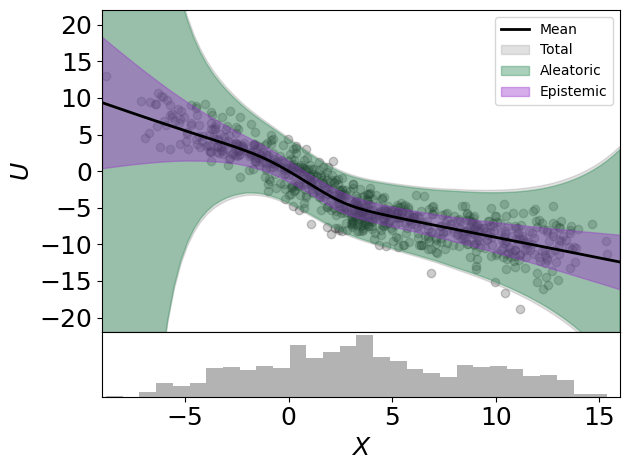

In [24]:
# Calculate epistemic and aleatoric and total variances
samples_mean = samples["_RETURN"][..., 0]
# Mean prediction is mean of mean
mean_pred = torch.mean(samples_mean, dim=0)

# Aleatoric is mean of variance (integrated over all parameters)
samples_sigma2 =  (torch.exp(samples["_RETURN"][..., 1])+model.eps)**2
aleatoric_var = torch.mean(samples_sigma2, dim=0)

# Epistemic is variance of conditional mean (ignoring aleatoric uncertainty)
epistemic_var = torch.var(samples_mean, dim=0)
# Law of total variances
total_var = aleatoric_var + epistemic_var

# Set up plot
plt.clf()
figure, (ax1, ax2) = plt.subplots(2, 1, sharex=True, 
    gridspec_kw={'height_ratios': [5, 1], 'hspace':0})

# Plot raw data
plt.sca(ax1)
plt.scatter(X_torch.flatten()[::], Y_torch.flatten()[::], color="k", alpha=0.2)
plt.axis(ymin=Ymin, ymax=Ymax, xmin=Xmin, xmax=Xmax)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.xlabel("$X$", fontsize=18)
plt.ylabel("$U$", fontsize=18)
plt.tight_layout()


# Both
plt.plot(X_domain.squeeze(), mean_pred, color="k", linewidth=2, label="Mean")
plt.fill_between(X_domain.squeeze(), 
                mean_pred - 2*np.sqrt(total_var), 
                mean_pred + 2*np.sqrt(total_var),
                color="dimgrey", alpha=0.2, label="Total")

# Aleatoric
plt.fill_between(X_domain.squeeze(), 
                mean_pred - 2*np.sqrt(aleatoric_var), 
                mean_pred + 2*np.sqrt(aleatoric_var),
                color="seagreen", alpha=0.4, label="Aleatoric")
# Epistemic
plt.fill_between(X_domain.squeeze(), 
                mean_pred - 2*np.sqrt(epistemic_var), 
                mean_pred + 2*np.sqrt(epistemic_var),
                color="darkorchid", alpha=0.4, label="Epistemic")

plt.legend()
plt.axis(ymin=Ymin, ymax=Ymax, xmin=Xmin, xmax=Xmax)
# Add histogram
plt.sca(ax2)
plot_hist(X_torch.flatten()[::], ax2)
plt.axis(ymin=0, xmin=Xmin, xmax=Xmax)
plt.yticks([], fontsize=18)
plt.xticks(fontsize=18)
plt.xlabel("$X$", fontsize=18)
plt.tight_layout()


Here we should see that the green uncertainty bands generally capture most of the variability in the data and that the purple bands show epistemic uncertainty due to uncertainty in the parameter values. We see wider uncertainties towards the edges of the dataset, where the model is less constrained. Note that extending training for more iterations or with more data does reduce this (e.g., see results plots in paper or run the full training script).

### Summary

This notebook trained a Bayesian neural network parameterisation $U_\text{BNN}(X)$ for the Lorenz 1996 system using stochastic variational inference in Pyro. The result is not just a learned mapping from coarse-scale state $X$ to subgrid forcing $U$, but also an estimate of the uncertainty over both the network weights (epistemic) and the training data (aleatoric). We will use this in the next notebook to draw samples from each type of uncertainty, creating a stochastic parameterisation. From here, we will study how uncertainty propagates in online simulations. 